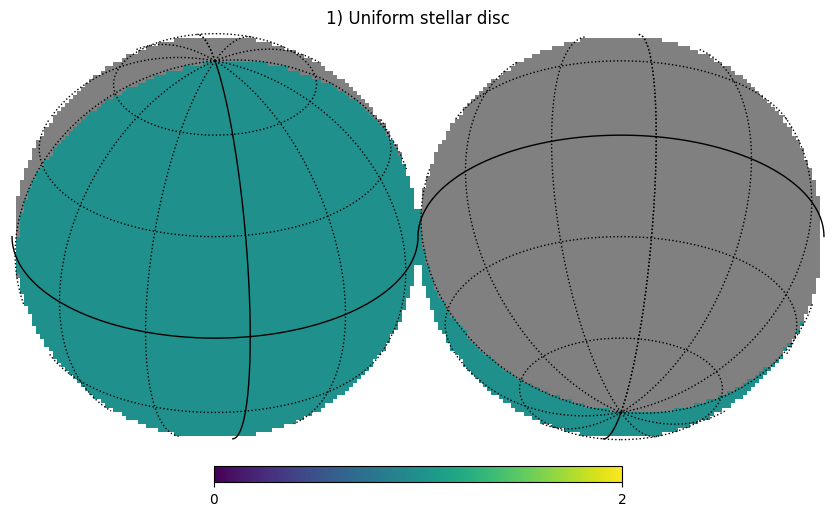

In [37]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

# inline plotting
%matplotlib inline

# 1) MAKE A MAP OF A STAR
# -----------------------
NSIDE = 128
NPIX  = hp.nside2npix(NSIDE)
ipix  = np.arange(NPIX)

# get unit vectors for every pixel
x, y, z = hp.pix2vec(NSIDE, ipix)
theta, phi = hp.pix2ang(NSIDE, ipix)

# define the visible hemisphere (observer along +z)
visible = x > 0

# uniform‐brightness map
star_map = np.full(NPIX, hp.UNSEEN)
star_map[visible] = 1.0

# # plot with a gnomonic projection centered on the sub‐observer point
# hp.gnomview(
#     star_map,
#     rot=[0, 90],           # rotate so that +z is in center
#     title="1) Uniform stellar disc",
#     xsize=200,
# )
# hp.graticule()

hp.orthview(
    star_map,
    rot=[10, 30],           # rotate so that +z is in center
    title="1) Uniform stellar disc",
    xsize=200,
)
hp.graticule()


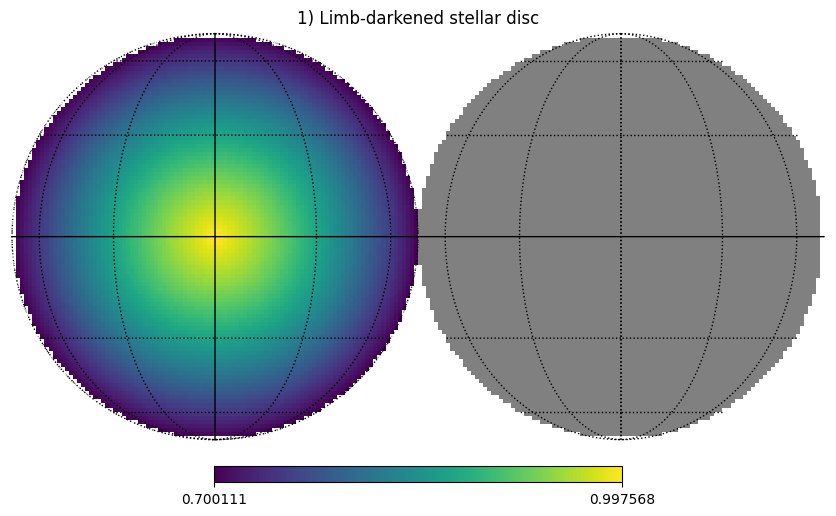

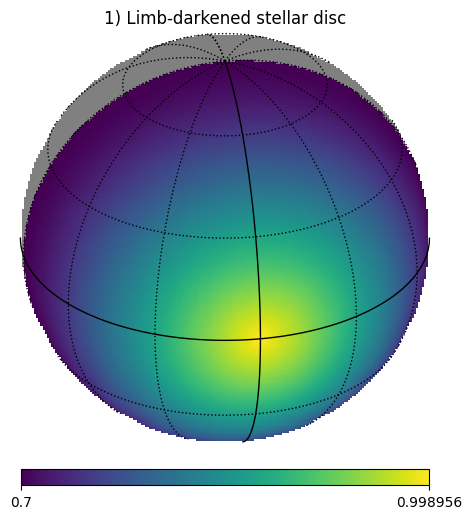

In [38]:
# Adding limb darkening

def quad_limb_dark(mu, u1, u2):
    """
    Compute the quadratic limb-darkening profile.

    Parameters
    ----------
    mu : array_like
        Cosine of the angle from the surface normal (μ = cos θ), between 0 and 1.
    u1, u2 : float
        Quadratic limb-darkening coefficients.

    Returns
    -------
    I_over_I0 : ndarray
        Normalized intensity I(μ)/I(1).
    """
    mu = np.asarray(mu)
    return 1.0 - u1*(1.0 - mu) - u2*(1.0 - mu)**2

# Example usage:
# mu = np.linspace(0, 1, 100)
# profile = quad_limb_dark(mu, u1=0.3, u2=0.2)


for pix in ipix[visible]:
    # mu = y^2 + z^2
    mu = 1-np.sqrt(y[pix]**2 + z[pix]**2)
    if mu > 1 or mu < 0:
        #make a warning
        print(f"Warning: mu value {mu} out of bounds for pixel {pix}.")

    mu = np.clip(mu, 0, 1)  # ensure mu is in [0, 1]

    # limb darkening coefficients
    u1, u2 = 0.2, 0.1

    # compute the intensity profile
    star_map[pix] = quad_limb_dark(mu, u1, u2)


# # plot with a gnomonic projection centered on the sub‐observer point
# hp.gnomview(
#     star_map,
#     rot=[0, 90],           # rotate so that +z is in center
#     title="1) Limb-Darkened stellar disc",
#     xsize=200,
# )
# hp.graticule()

hp.orthview(
    star_map,
    rot=[0, 0],           # rotate so that +z is in center
    title="1) Limb-darkened stellar disc",
    xsize=200,
)
hp.graticule()

hp.orthview(
    star_map,
    rot=[10, 30],           # rotate so that +z is in center
    title="1) Limb-darkened stellar disc",
    xsize=200,
    half_sky=True,  # show the whole sky
)
hp.graticule()


In [39]:
#Transit parameters
b=0.2
rp=0.15
n=1000
#
#  Manually calculating the transit chord
z_tr=np.ones(n) * b  # z values for the transit chord at impact parameter b
y_max_tr=np.sqrt(1-z_tr[0]**2)  # y_max for the transit chord

y_tr= np.linspace(-y_max_tr, y_max_tr, n)  # y values for the transit chord
x_tr = np.sqrt(1 - y_tr**2 - z_tr**2)  # x values for the transit chord
vec_tr=np.array([x_tr, y_tr, z_tr]).T  # vectors for the transit chord

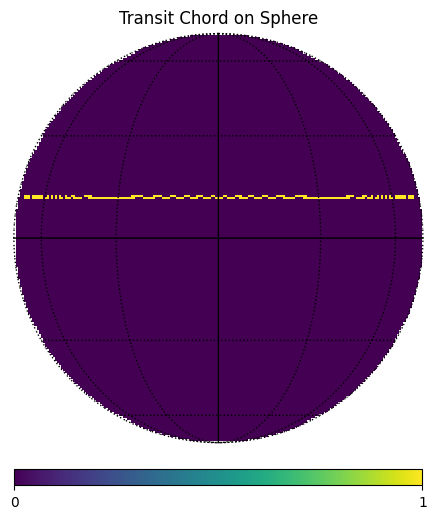

In [51]:
transit_map = np.full(NPIX, 0)  # initialize the transit map
for element in vec_tr:



    # Convert the vector to pixel index
    pix = hp.vec2pix(NSIDE, element[0], element[1], element[2])
    if pix >= 0 and pix < NPIX:  # Check if the pixel index is valid
        transit_map[pix] = 1  # Set the pixel value to the square of the radius

# 4) Display
hp.orthview(transit_map, title="Transit Chord on Sphere",half_sky=True, xsize=200)
hp.graticule()
plt.show()


In [41]:
vec_tr[500]

array([0.97979541, 0.00098078, 0.2       ])

---

In [54]:
pix

np.int64(78080)

In [56]:
pix<NPIX

np.True_

In [63]:
max(map_circle)

np.float64(1.0)

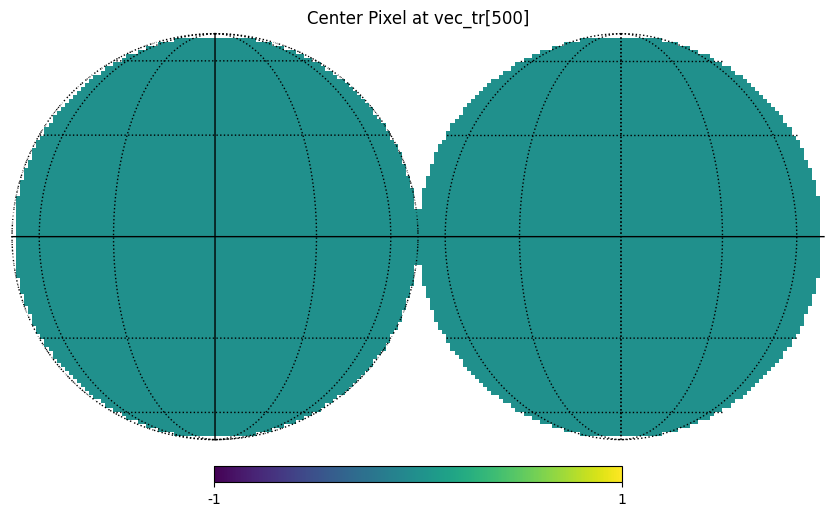

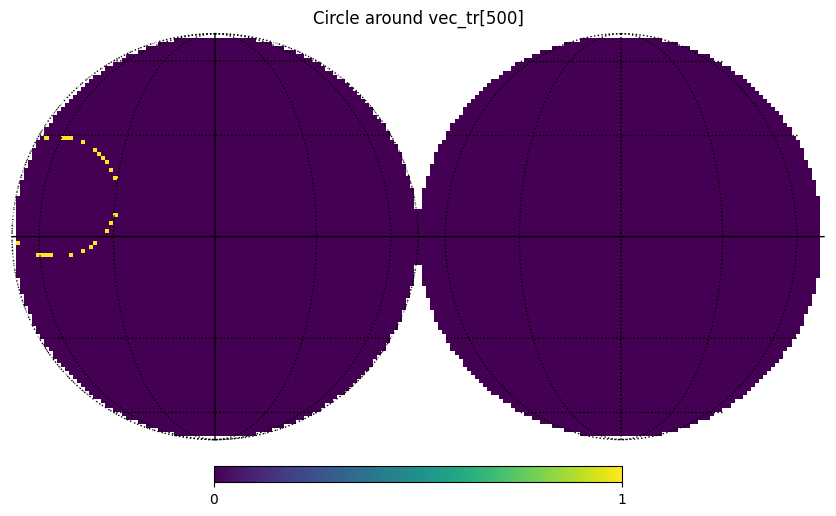

In [79]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

# assume NSIDE, NPIX, vec_tr are already defined

# pick the 500th direction
vec = vec_tr[900]

# make a map and mark the central pixel
map_circle = np.zeros(NPIX)
pix = hp.vec2pix(NSIDE, vec[0], vec[1], vec[2])
map_circle[pix] = 2
hp.orthview(map_circle, title="Center Pixel at vec_tr[500]", xsize=200)
hp.graticule()
plt.show()

# get center coords
x_center, y_center, z_center = vec
# draw a small “circle” in the local x–z plane around (x_center, z_center)
radius = 0.3   # small angular offset
theta  = np.linspace(0, 2*np.pi, 1000)
y_circle = y_center + radius * np.cos(theta)
z_circle = z_center + radius * np.sin(theta)

# solve for y so that x^2 + y^2 + z^2 = 1, keeping the same sign as y_center
x_circle = np.sign(x_center) * np.sqrt(
    np.clip(1.0 - y_circle**2 - z_circle**2, 0.0, 1.0)
)

# (Optional) check they’re all unit‐length
# r = np.sqrt(x_circle**2 + y_circle**2 + z_circle**2)
# print(np.max(np.abs(r - 1.0)))  # should be ≲1e-8

# turn those back into Healpix pixels
pix_circle = hp.vec2pix(NSIDE,
                        x_circle,
                        y_circle,
                        z_circle)

# build and plot the circle‐map
map_circle = np.zeros(NPIX)
map_circle[pix_circle] = 1.0

hp.orthview(map_circle,
            rot=[0,0],
            title="Circle around vec_tr[500]",
            xsize=200)
hp.graticule()
plt.show()

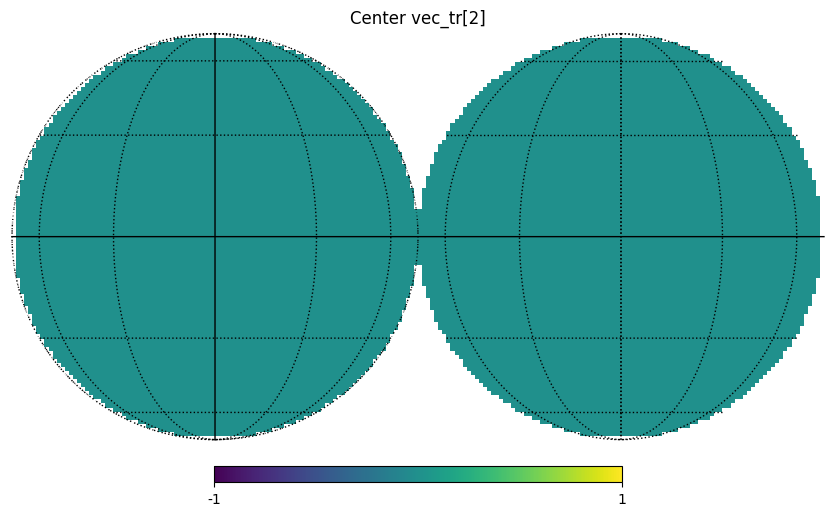

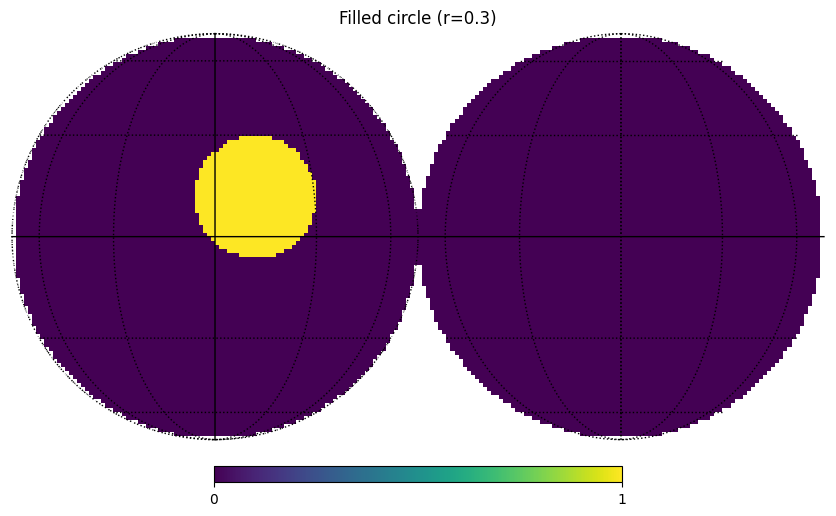

In [98]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from healpy.projector import OrthographicProj

# — assume NSIDE, NPIX, vec_tr are already defined —

# 1) Pick your direction (here the 3rd point on your chord)
vec = vec_tr[400]
x0, y0, z0 = vec

# 2) (Optional) mark the central pixel for reference
map_center = np.zeros(NPIX)
pix_center = hp.vec2pix(NSIDE, x0, y0, z0)
map_center[pix_center] = 2
hp.orthview(map_center, rot=[0,0], title="Center vec_tr[2]", xsize=200)
hp.graticule()
plt.show()

# 3) Create an orthographic projector centred on +Z:
proj = OrthographicProj(rot=[0,0], xsize=200)

# 4) Find the 2D plane coords of your center:
x_center, y_center = proj.vec2xy(x0, y0, z0)

# 5) Define your desired circle radius in plane‐units:
radius = 0.3   # same units as vec2xy() outputs

# 6) Build a polar grid (r, θ) filling [0, radius]:
Nrad  = 1000
Nang  = 1000
radii = np.linspace(0, radius, Nrad)
thetas = np.linspace(0, 2*np.pi, Nang, endpoint=False)
rr, tt = np.meshgrid(radii, thetas, indexing='xy')

# 7) Convert to plane‐coordinates (x, y):
xs = x_center + rr * np.cos(tt)
ys = y_center + rr * np.sin(tt)

# 8) Back‐project every (x, y) → unit‐vector on the sphere:
vecs = np.array(proj.xy2vec(xs.ravel(), ys.ravel())).T

# 9) Filter out any invalid/backside points (if any):
valid = ~np.isnan(vecs).any(axis=1)
vecs  = vecs[valid]

# 10) Map those vectors to Healpix pixels:
pix_fill = hp.vec2pix(NSIDE,
                      vecs[:,0],
                      vecs[:,1],
                      vecs[:,2])

pix_fill = np.unique(pix_fill)  # remove duplicates

# 11) Make your “filled circle” map and plot it:
map_fill = np.zeros(NPIX)
map_fill[pix_fill] = 1.0

hp.orthview(map_fill,
            rot=[0,0],
            title=f"Filled circle (r={radius})",
            xsize=200)
hp.graticule()
plt.show()
